Dataset shape: (920, 14)
Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

Target distribution (num):
 num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

=== Custom Decision Tree (from scratch) ===
Accuracy: 0.6032608695652174

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.87      0.80        82
           1       0.51      0.64      0.57        53
           2       0.27      0.14      0.18        22
           3       0.22      0.10      0.13        21
           4       1.00      0.17      0.29         6

    accuracy                           0.60       184
   macro avg       0.55      0.38      0.39       184
weighted avg       0.57      0.60      0.57       184



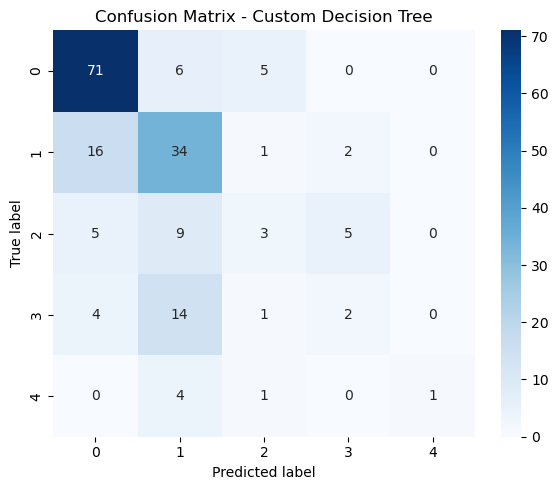


=== Sklearn DecisionTreeClassifier (baseline) ===
Accuracy: 0.5978260869565217

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.87      0.80        82
           1       0.47      0.66      0.55        53
           2       0.33      0.05      0.08        22
           3       0.22      0.10      0.13        21
           4       1.00      0.17      0.29         6

    accuracy                           0.60       184
   macro avg       0.55      0.37      0.37       184
weighted avg       0.56      0.60      0.55       184



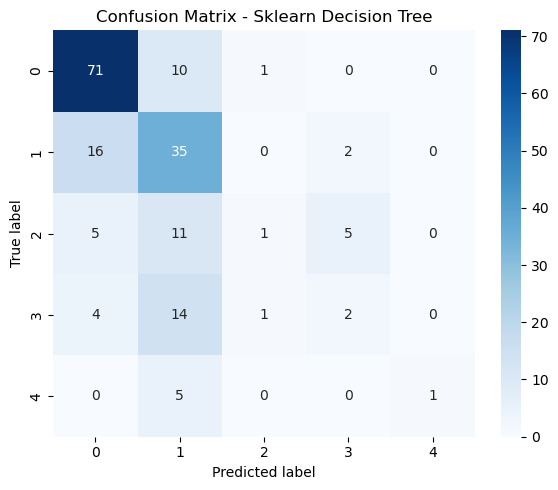


Feature importances (sklearn):
cp        : 0.369
chol      : 0.154
age       : 0.119
ca        : 0.095
oldpeak   : 0.085
exang     : 0.058
trestbps  : 0.047
thalch    : 0.044
sex       : 0.029
fbs       : 0.000
restecg   : 0.000
slope     : 0.000
thal      : 0.000


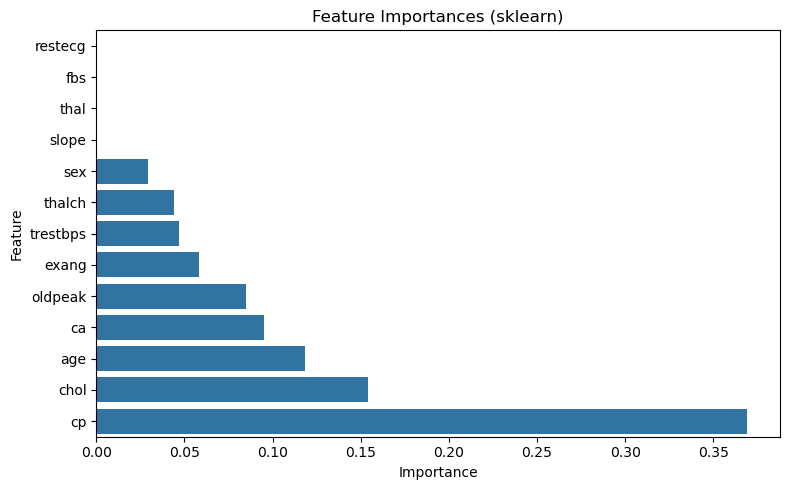

In [7]:



import numpy as np
import pandas as pd
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.tree import DecisionTreeClassifier 

import matplotlib.pyplot as plt
import seaborn as sns


DATA_PATH = r"C:\Users\sabar\Downloads\heart_disease_clean_tree_fixed (1).csv"


def load_and_preprocess_data(path: str):
   
    df = pd.read_csv(path)

    print("Dataset shape:", df.shape)
    print("Missing values per column:\n", df.isna().sum())
    print("\nTarget distribution (num):\n", df["num"].value_counts())

    X = df.drop(columns=["num"])
    y = df["num"].astype(int)

    feature_names = X.columns.tolist()
    return X.values, y.values, feature_names



class DecisionTreeNode:
  
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, *, value=None):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  

    def is_leaf(self):
        return self.value is not None


class MyDecisionTreeClassifier:
   
    def __init__(self, max_depth=None, min_samples_split=2, min_impurity_decrease=1e-7):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_impurity_decrease = min_impurity_decrease
        self.n_classes_ = None
        self.n_features_ = None
        self.tree_ = None

    # ---- impurity (Gini) ----
    def _gini(self, y):
        m = len(y)
        if m == 0:
            return 0.0
        counts = np.bincount(y)
        probs = counts / m
        return 1.0 - np.sum(probs ** 2)

    # ---- best split search ----
    def _best_split(self, X, y):
       
        m, n = X.shape
        if m < self.min_samples_split:
            return None, None, None, None

        parent_impurity = self._gini(y)
        best_impurity = np.inf
        best_feature = None
        best_threshold = None
        best_left_idx = None
        best_right_idx = None

        for feature_index in range(n):
            x_col = X[:, feature_index]

         
            sorted_idx = np.argsort(x_col)
            x_sorted = x_col[sorted_idx]
            y_sorted = y[sorted_idx]

            
            if np.all(x_sorted == x_sorted[0]):
                continue

        
            for i in range(1, m):
                if y_sorted[i] == y_sorted[i - 1]:
                    continue

                threshold = (x_sorted[i] + x_sorted[i - 1]) / 2.0
                left_mask = x_col <= threshold
                right_mask = ~left_mask

                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                y_left, y_right = y[left_mask], y[right_mask]
                impurity = (
                    len(y_left) * self._gini(y_left)
                    + len(y_right) * self._gini(y_right)
                ) / m

                if impurity < best_impurity - 1e-12:
                    best_impurity = impurity
                    best_feature = feature_index
                    best_threshold = threshold
                    best_left_idx = left_mask
                    best_right_idx = right_mask

        impurity_decrease = parent_impurity - (best_impurity if best_feature is not None else parent_impurity)

        if best_feature is None or impurity_decrease < self.min_impurity_decrease:
            return None, None, None, None

        return best_feature, best_threshold, best_left_idx, best_right_idx

    # ---- recursive tree building ----
    def _build_tree(self, X, y, depth):
        num_samples = len(y)
        num_labels = len(np.unique(y))

       
        if (self.max_depth is not None and depth >= self.max_depth) or \
           num_labels == 1 or \
           num_samples < self.min_samples_split:
            leaf_value = Counter(y).most_common(1)[0][0]
            return DecisionTreeNode(value=leaf_value)

        feature, threshold, left_idx, right_idx = self._best_split(X, y)

     
        if feature is None:
            leaf_value = Counter(y).most_common(1)[0][0]
            return DecisionTreeNode(value=leaf_value)

        left_subtree = self._build_tree(X[left_idx], y[left_idx], depth + 1)
        right_subtree = self._build_tree(X[right_idx], y[right_idx], depth + 1)

        return DecisionTreeNode(
            feature_index=feature,
            threshold=threshold,
            left=left_subtree,
            right=right_subtree,
        )

    
    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y, dtype=int)

        self.n_classes_ = len(np.unique(y))
        self.n_features_ = X.shape[1]
        self.tree_ = self._build_tree(X, y, depth=0)
        return self

    def _predict_one(self, x, node: DecisionTreeNode):
        if node.is_leaf():
            return node.value
        if x[node.feature_index] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def predict(self, X):
        X = np.asarray(X)
        return np.array([self._predict_one(row, self.tree_) for row in X])




def plot_confusion_matrix(cm, class_labels, title="Confusion Matrix"):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_feature_importances(importances, feature_names, title="Feature Importances (sklearn)"):
    sorted_idx = np.argsort(importances)
    sorted_importances = importances[sorted_idx]
    sorted_names = np.array(feature_names)[sorted_idx]

    plt.figure(figsize=(8, 5))
    sns.barplot(x=sorted_importances, y=sorted_names)
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def main():
    X, y, feature_names = load_and_preprocess_data(DATA_PATH)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )


    my_tree = MyDecisionTreeClassifier(
        max_depth=5,          
        min_samples_split=5,  
        min_impurity_decrease=1e-4
    )
    my_tree.fit(X_train, y_train)
    y_pred = my_tree.predict(X_test)

    print("\n=== Custom Decision Tree (from scratch) ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    class_labels = sorted(np.unique(y))
    plot_confusion_matrix(cm, class_labels, title="Confusion Matrix - Custom Decision Tree")

   
    sk_tree = DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    )
    sk_tree.fit(X_train, y_train)
    sk_y_pred = sk_tree.predict(X_test)

    print("\n=== Sklearn DecisionTreeClassifier (baseline) ===")
    print("Accuracy:", accuracy_score(y_test, sk_y_pred))
    print("\nClassification Report:\n", classification_report(y_test, sk_y_pred))

    sk_cm = confusion_matrix(y_test, sk_y_pred)
    plot_confusion_matrix(sk_cm, class_labels, title="Confusion Matrix - Sklearn Decision Tree")

   
    importances = sk_tree.feature_importances_
    print("\nFeature importances (sklearn):")
    for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
        print(f"{name:10s}: {imp:.3f}")

    plot_feature_importances(importances, feature_names)


if __name__ == "__main__":
    main()
